# Om Mehta
# Assignment 2
# FINM 34700

In [147]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal`f
import matplotlib.pyplot as plt

## 1. Basic PCA

In [5]:
df = pd.read_csv("ladyrun25.dat", delimiter="\t", header=None)
df.columns=["Country","100m","200m","400m","800m","1500m","3000m","Marathon"]
df.set_index('Country', inplace=True)

In [6]:
mu = df.mean()
sigma = df.std()
X = (df - mu)/sigma

### a)

In [7]:
r = X.corr()
eigvals, eigvecs = np.linalg.eigh(r)
eigvals = eigvals[::-1]
eigvecs = eigvecs[:, ::-1]

In [8]:
a1, a2 = eigvecs[0], eigvecs[1]
PC1 = X @ a1
PC2 = X @ a2
PC_1_2 = pd.DataFrame({'PC1': PC1, 'PC2': PC2}, index=df.index)
PC_1_2

,PC1,PC2
Country,,
ARG,0.051756,0.069578
AUS,0.843175,1.376030
AUT,0.780836,0.780049
BEL,0.865400,1.181213
BER,0.222311,-1.026740
BRA,0.767635,0.647659
CAN,0.881993,1.401075
CHI,-0.575881,-0.928736
CHN,1.407448,2.519440


The scaled variables are standardized to measure dispersion from their respective means, and the principal components aim to capture where this dispersion is the most across the data. 

### b)

In [9]:
eigvecs_df = pd.DataFrame({'a1':a1, 'a2':a2})
eigvecs_df.set_index(X.columns)

,a1,a2
100m,-0.372034,-0.373878
200m,-0.457520,-0.480156
400m,-0.148702,-0.074238
800m,-0.526291,-0.111315
1500m,-0.154502,-0.091645
3000m,0.567743,-0.749526
Marathon,0.083481,-0.203899


The eigenvectors show that PC1 is a roughly equal-weighted combination of all distances, indicating an overall performance factor. PC2 contrasts sprint events (high negative loadings for 100m/200m) with endurance events (positive loadings for Marathon/3000m), indicating a short- vs long-distance tradeoff.

### c)

In [10]:
explained_variance_ratio = eigvals / np.sum(eigvals)
pc_labels = [f"PC{i+1}" for i in range(len(explained_variance_ratio))]
explained_df = pd.DataFrame({
    "Principal Component": pc_labels,
    "Variance Explained": explained_variance_ratio
})
explained_df["Variance Explained"] = explained_df["Variance Explained"].map(lambda x: f"{x*100:.2f}%")
explained_df.set_index("Principal Component", inplace=True)
explained_df

,Variance Explained
Principal Component,
PC1,81.45%
PC2,10.53%
PC3,4.12%
PC4,1.63%
PC5,1.23%
PC6,0.72%
PC7,0.31%


Just about 92% of the variance in the data can be explained by the first two principal components. Specifically, **PC1** accounts for **81.45%** and **PC2** accounts for **10.53%**.

### d)

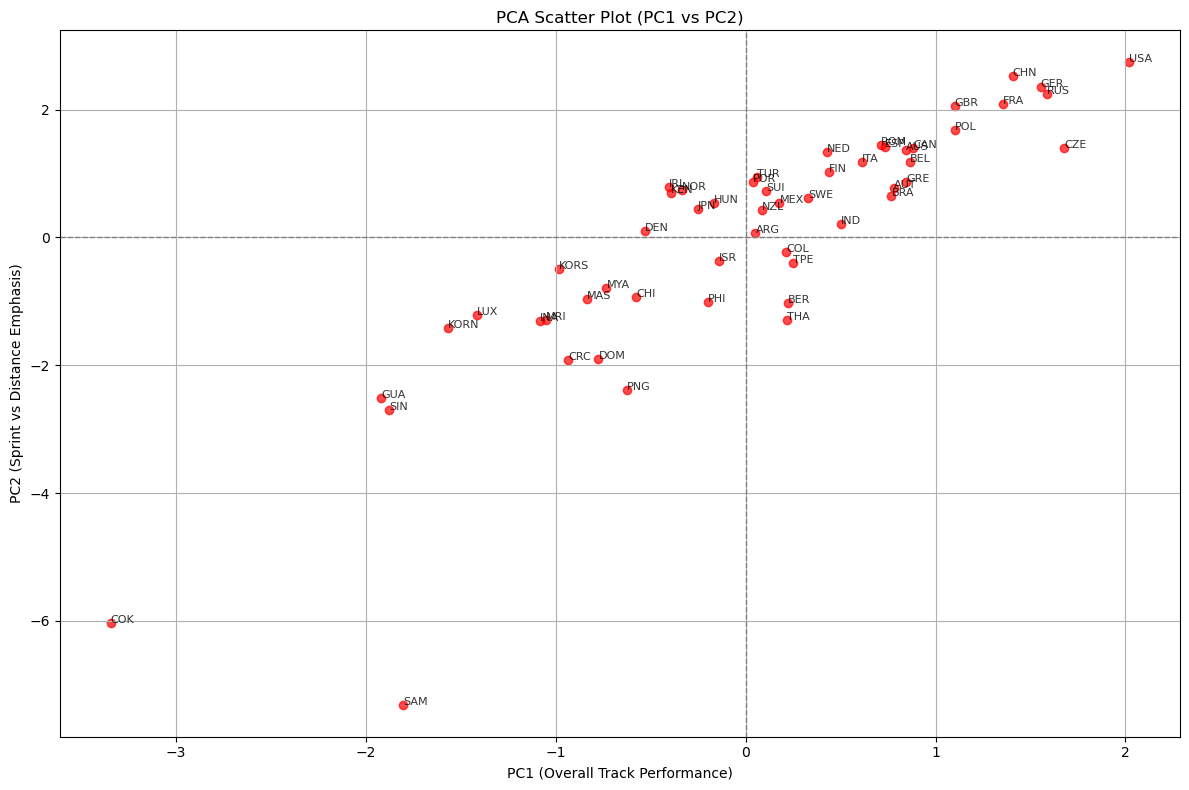

In [11]:
plt.figure(figsize=(12, 8))
plt.scatter(PC_1_2["PC1"], PC_1_2["PC2"], color='red', alpha=0.7)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

for country, (x, y) in PC_1_2.iterrows():
    plt.text(x, y, country, fontsize=8, alpha=0.8)

# Titles and axis labels
plt.title("PCA Scatter Plot (PC1 vs PC2)")
plt.xlabel("PC1 (Overall Track Performance)")
plt.ylabel("PC2 (Sprint vs Distance Emphasis)")
plt.grid(True)
plt.tight_layout()
plt.show()

Since most PC1 loadings are negative, and we are dealing with data that says smaller numbers = better performance, high PC1 scores mean high performance.

In [12]:
comparison = pd.DataFrame({
    "PC1 Score": PC_1_2["PC1"],
    "Avg Time": df.mean(axis=1)
})

comparison.sort_values("PC1 Score", ascending=False).head(10)

,PC1 Score,Avg Time
Country,,
USA,2.019620,33.487143
CZE,1.677651,34.432857
RUS,1.586092,33.888571
GER,1.554930,33.378571
CHN,1.407448,33.065714
FRA,1.353492,34.794286
GBR,1.101638,33.130000
POL,1.101405,34.427143
CAN,0.881993,34.964286


This comparison is consistent with the conclusion that **high PC1 scores $\rightarrow$ low times**.

### d)

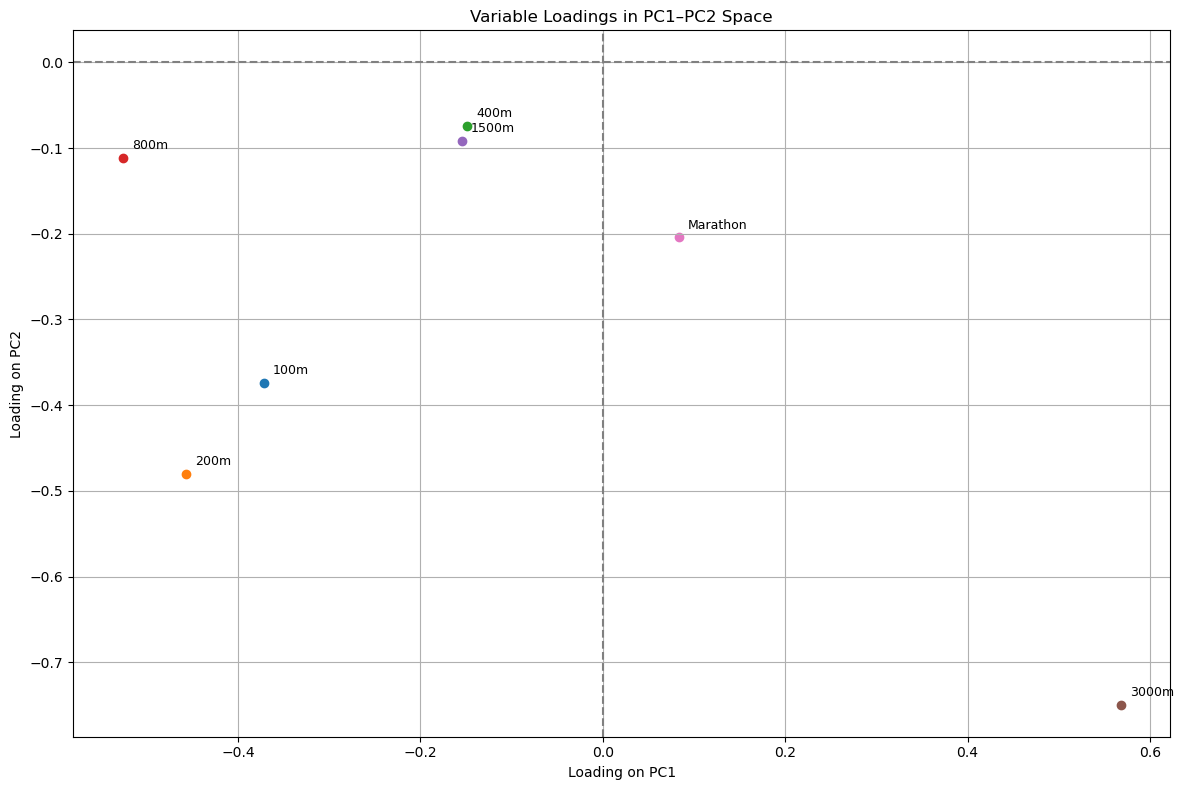

In [13]:
plt.figure(figsize=(12, 8))
for i, var in enumerate(X.columns):
    plt.scatter(a1[i], a2[i])
    plt.text(a1[i] + 0.01, a2[i] + 0.01, var, fontsize=9)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title("Variable Loadings in PC1–PC2 Space")
plt.xlabel("Loading on PC1")
plt.ylabel("Loading on PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


In the loading plot, **PC1** clearly separates short-distance events (100m, 200m) from long-distance ones (Marathon, 3000m), confirming that PC1 reflects an underlying speed vs endurance axis. **PC2**, by contrast, shows only minor variation among variables and no obvious clustering, suggesting it captures a weaker secondary pattern that is less interpretable from loadings alone.

## 2. Scaling Effects in PCA

In [14]:
df = pd.read_csv('Harman5.txt', delim_whitespace=True)
df

/var/folders/xp/4nc8f7g91gv5x06rht7jb6zw0000gn/T/ipykernel_1187/4138633628.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('Harman5.txt', delim_whitespace=True)


,population,schooling,employment,professional,housevalue
Tract1,5700,12.8,2500,270,25000
Tract2,1000,10.9,600,10,10000
Tract3,3400,8.8,1000,10,9000
Tract4,3800,13.6,1700,140,25000
Tract5,4000,12.8,1600,140,25000
Tract6,8200,8.3,2600,60,12000
Tract7,1200,11.4,400,10,16000
Tract8,9100,11.5,3300,60,14000
Tract9,9900,12.5,3400,180,18000
Tract10,9600,13.7,3600,390,25000


### a)

### General functionality for loadings given a cov/corr matrix

In [42]:
def get_loadings(sigma):
    eigvals, eigvecs = np.linalg.eigh(sigma)
    lambdas = eigvals[::-1]
    e = eigvecs[:, ::-1]
    total_var = np.sum(lambdas)
    explained_variance = lambdas / np.sum(lambdas)
    pc_labels = [f"PC{i+1}" for i in range(len(explained_variance))]
    explained_df = pd.DataFrame({
        "Principal Component": pc_labels,
        "Variance Explained": explained_variance
    })
    explained_df["Variance Explained"] = explained_df["Variance Explained"].map(lambda x: f"{x*100:.2f}%")
    explained_df.set_index("Principal Component", inplace=True)
    e_df = pd.DataFrame(e, columns=pc_labels, index=df.columns)
    e_df = e_df.map(lambda x: f"{x*100:.2f}%")
    return explained_df.T, e_df

### Using unscaled data - covariance matrix

In [99]:
S = df.cov()
proportions_unscaled, loadings_unscaled = get_loadings(S)
proportions_unscaled

Principal Component,PC1,PC2,PC3,PC4,PC5
Variance Explained,75.26%,24.62%,0.11%,0.01%,0.00%


### Using scaled data - correlation matrix

In [100]:
R = df.corr()
proportions_scaled, loadings_scaled = get_loadings(R)
proportions_scaled

Principal Component,PC1,PC2,PC3,PC4,PC5
Variance Explained,57.47%,35.93%,4.30%,2.00%,0.31%


In the first case, using the **unscaled** data in the form of a **covariance matrix**, just PC1 is sufficient to capture 75% of the variability in the data. In the second case, using the **scaled** data in the form of a correlation matrix, which normalizes the covariance matrix, PC1 and PC2 are needed to capture 75% of the variability in the data.

### b)

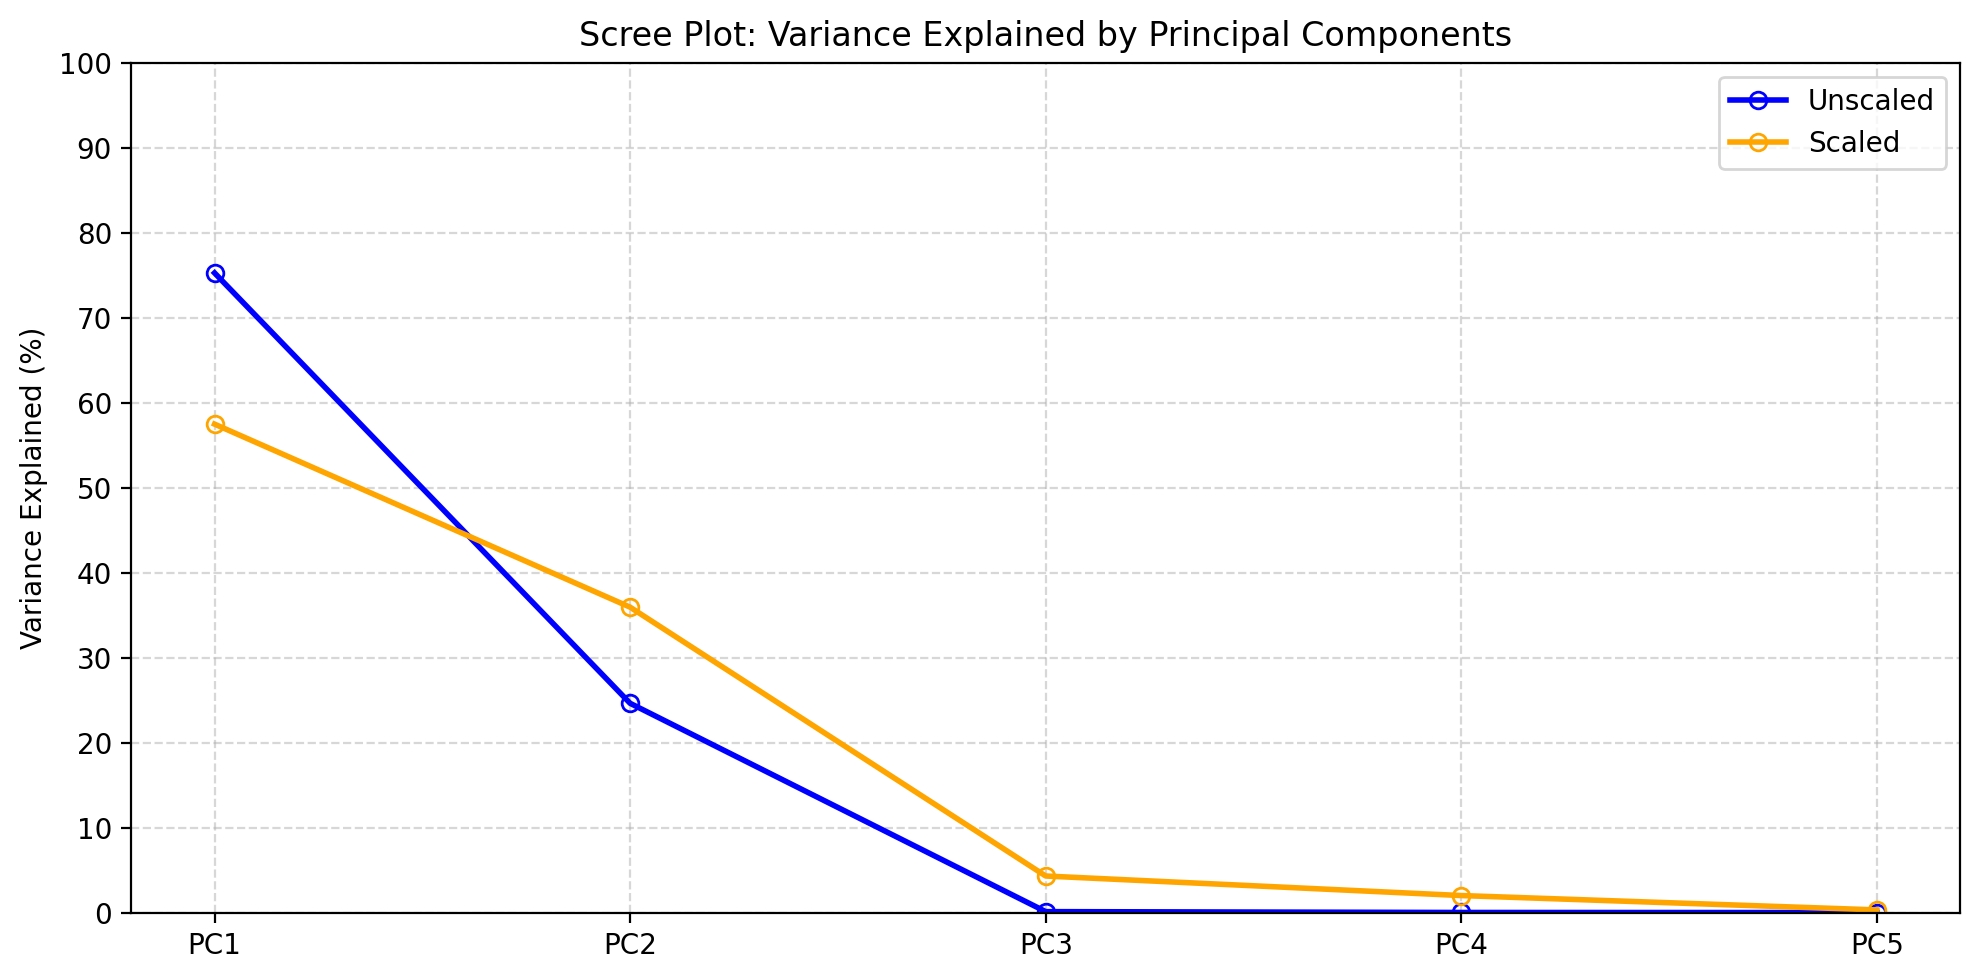

In [146]:
proportions_unscaled = [75.26, 24.62, 0.11, 0.01, 0.00]
proportions_scaled   = [57.47, 35.93, 4.30, 2.00, 0.31]
pcs = ["PC1", "PC2", "PC3", "PC4", "PC5"]

x = np.arange(len(pcs))

fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

# Plot line for unscaled
ax.plot(x, proportions_unscaled, label='Unscaled', color='blue', marker='o',
        linestyle='-', linewidth=2, markersize=6, fillstyle='none')

# Plot line for scaled
ax.plot(x, proportions_scaled, label='Scaled', color='orange', marker='o',
        linestyle='-', linewidth=2, markersize=6, fillstyle='none')

# Set axes and labels
ax.set_ylabel('Variance Explained (%)')
ax.set_xticks(x)
ax.set_xticklabels(pcs)
ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_title('Scree Plot: Variance Explained by Principal Components')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### c)

In [103]:
display(loadings_unscaled, loadings_scaled)

,PC1,PC2,PC3,PC4,PC5
population,-2.10%,-94.30%,33.21%,0.57%,-0.07%
schooling,-0.02%,0.00%,-0.20%,-0.07%,-100.00%
employment,-2.69%,-33.13%,-94.29%,2.39%,0.19%
professional,-1.42%,-1.29%,-2.04%,-99.96%,0.07%
housevalue,-99.93%,2.90%,1.87%,1.34%,0.02%


,PC1,PC2,PC3,PC4,PC5
population,-34.27%,60.16%,-5.95%,20.40%,-68.95%
schooling,-45.25%,-40.64%,-68.88%,-35.36%,-17.49%
employment,-39.67%,54.17%,-24.80%,2.29%,69.80%
professional,-55.01%,-7.78%,66.41%,-50.04%,0.01%
housevalue,-46.67%,-41.64%,13.96%,76.32%,8.24%


It's clear here that the **scaled** loadings capture the true picture here. If we go back to examine the dataset, we see that the `housevalue` column is most of the time a 5-digit number, whereas the other variables are a lot smaller. So, obviously, without normalizing for this, that column will hold the most "variance." This is also consistent with the fact that most of the variance is explained in the first principal component for the unscaled data. Regardless, the scaled data shows a much more complete picture.

## 3. Simulation on consistency and sparsity of high-dimensional PCA

### a)

Since $\boldsymbol{v}_1$ is the eigenvector of the largest eigenvalue of $\Sigma$, which is the population covariance matrix, we can expect $\hat{\boldsymbol{e}}_1$ to converge to $\boldsymbol{v}_1$ as $n \rightarrow \infty$. So, $\rho = corr(\hat{\boldsymbol{e}}_1,\boldsymbol{v}_1) \approx 1$. And likewise, $|\rho| \approx 1$.

### b)

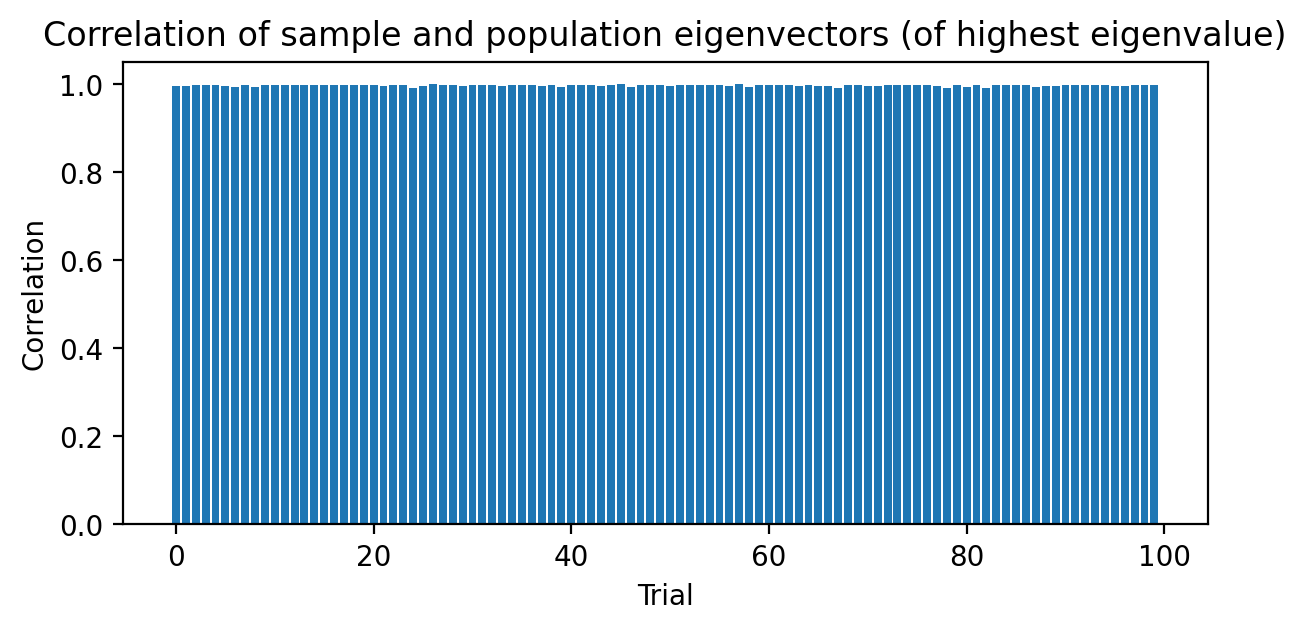

In [132]:
def run_and_plot_sim(p, n, M):
          
    rhos = []
    
    C = np.random.randn(p, p)
    Sigma = C @ C.T 
    
    _, pop_vecs = np.linalg.eigh(Sigma)
    v1 = pop_vecs[:, 0]  
    
    for _ in range(M):
        X = np.random.multivariate_normal(mean=np.zeros(p), cov=Sigma, size=n)
        sample_cov = np.cov(X, rowvar=False)
        
        _, sample_vecs = np.linalg.eigh(sample_cov)
        e1 = sample_vecs[:, 0]
        
        rho = np.corrcoef(e1, v1)[0, 1]
        rhos.append(abs(rho)) 
    plt.figure(figsize=(7, 3), dpi=200)
    plt.bar(np.arange(len(rhos)), [np.abs(rho) for rho in rhos])
    plt.title('Correlation of sample and population eigenvectors (of highest eigenvalue)')
    plt.xlabel('Trial')
    plt.ylabel('Correlation')
    plt.show()

run_and_plot_sim(10, 50, 100)

The histogram **agrees** with my hypothesis that the sample correlations tend to 1.

### c)

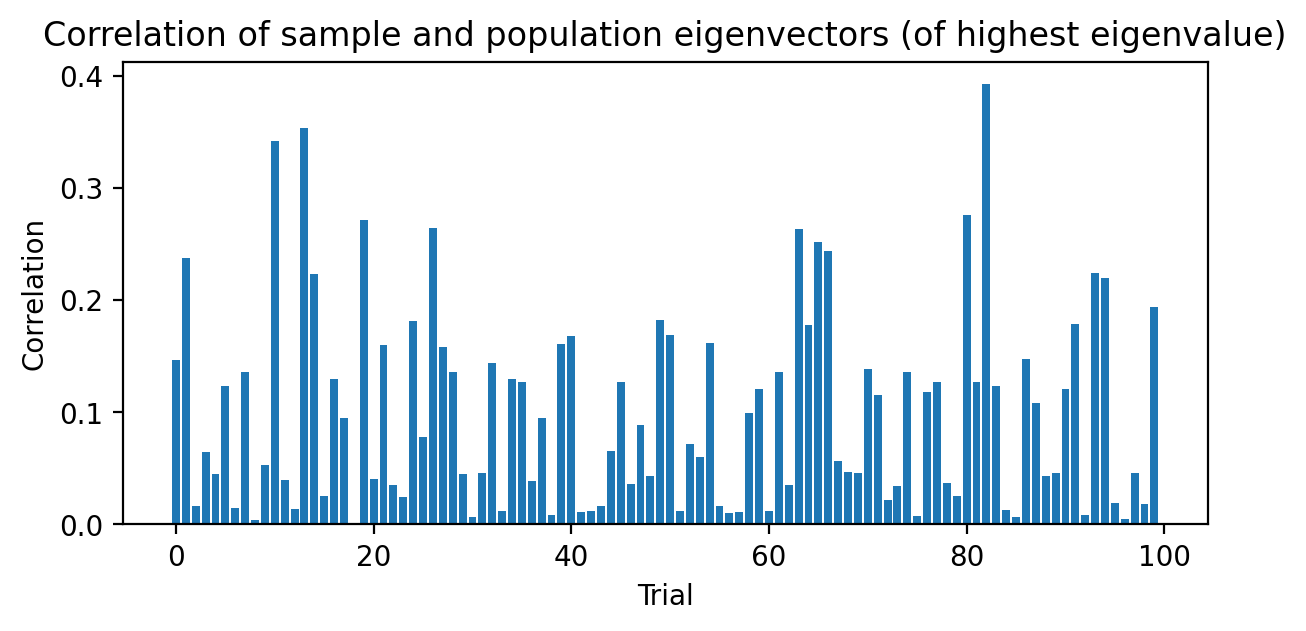

In [140]:
run_and_plot_sim(100, 50, 100)

The correlations **break down here** because as the dimensionality $p$ grows larger and $n$ stays the same, we are effectively trying to conclude too much from not enough data. As dimensionality increases (especially without an increase in sample size), random vectors start to become **nearly orthogonal** to each other. In high dimensions with limited samples, random fluctuations in the data start to dominate.

### d)

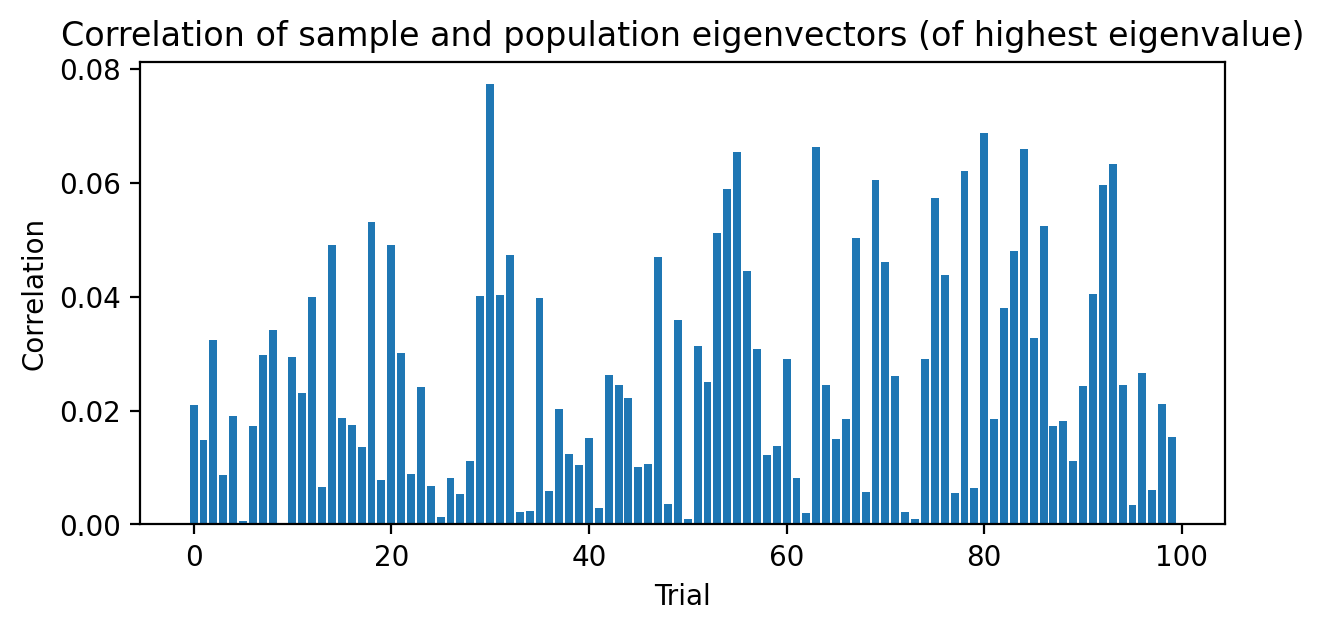

In [144]:
run_and_plot_sim(1000, 50, 100)

1000 simulations was the best I could do. Correlations are near 0 here which makes sense. Safe to say that when $p\geq n$, correlations break down fairly exponentially.

### e)

First off, the L shape in the scree plot is saying most if not all the variability is described by PC1. More importantly, the researcher is using $p=4000$ and $n=100$ which is guaranteed to give an unstable sample covariance, because the amount of samples is less than 10% of the amount of features. **What PCA is actually optimizing for** is where there's the most variance. In an unsupervised sense, there's no real explainability here, there's a **misinterpretation** of what a "high loading" on PC1 actually means. 

## 4. Factor Analysis using PC and ML methods

In [149]:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

### a)

In [170]:
df_centered = df - df.mean()
S_normal = df_centered.cov()      # for part i.
df_scaled = df_centered/df.std()
S_scaled = df_scaled.cov()        # for part ii.

In [176]:
normal_loadings = pd.DataFrame(index=df.columns)
scaled_loadings = pd.DataFrame(index=df.columns)
for i, S in enumerate([S_normal, S_scaled]):
    eigvals, eigvecs  = np.linalg.eigh(S)
    lambdas = eigvals[::-1]
    v = eigvecs[:, ::-1]
    v1, v2 = v[0], v[1]
    v1 *= np.sqrt(lambdas[0])
    v2 *= np.sqrt(lambdas[1])
    if i == 0:
        normal_loadings['l1'] = v1
        normal_loadings['l2'] = v2
    else:
        scaled_loadings['l1'] = v1
        scaled_loadings['l2'] = v2

In [178]:
display(normal_loadings, scaled_loadings)

,l1,l2
population,-133.999111,-0.881979
schooling,-6007.919017,0.030903
employment,2115.519470,-7.310541
professional,36.390806,-2.417342
housevalue,-4.286687,-3644.082805


,l1,l2
population,-0.580957,-0.606538
schooling,1.019813,-0.544756
employment,-0.100887,-0.923295
professional,0.345853,-0.473924
housevalue,-1.168757,-0.234383


### b)

In [180]:
fa = FactorAnalysis(n_components=2)
fa.fit(df)
L_mle = fa.components_.T
Psi_mle = fa.noise_variance_
loadings_df = pd.DataFrame(L_mle, index=df.columns, columns=['Factor1', 'Factor2'])
psi_df = pd.DataFrame(Psi_mle, index=df.columns, columns=['Specific Variance'])
display(loadings_df)
display(psi_df)

,Factor1,Factor2
population,73.894392,-3291.776602
schooling,1.476270,0.015161
employment,144.921667,-1153.007804
professional,85.570137,-46.410813
housevalue,6096.445332,0.149815


,Specific Variance
population,6174.065651
schooling,0.746161
employment,61784.810125
professional,2631.420411
housevalue,20.957045


### c)

In [198]:
residual_pca = S_normal - (normal_loadings @ normal_loadings.T)
residual_mle = S_normal - (L_mle @ L_mle.T + Psi_mle)

In [199]:
residual_pca

,population,schooling,employment,professional,housevalue
population,1.181560e+07,-8.049959e+05,4.435592e+06,178381.779434,4.871207e+05
schooling,-8.049959e+05,-3.609509e+07,1.271021e+07,218775.055083,-1.582327e+04
employment,4.435592e+06,1.271021e+07,-2.934870e+06,-3578.889282,9.460647e+05
professional,1.783818e+05,2.187751e+05,-3.578889e+03,11878.198996,5.604379e+05
housevalue,4.871207e+05,-1.582327e+04,9.460647e+05,560437.911155,2.726610e+07


In [200]:
residual_mle

,population,schooling,employment,professional,housevalue
population,986132.962295,-0.002144,284183.392021,11778.973213,4.088817e+04
schooling,-6173.321634,0.265978,-61639.151236,-2615.079258,7.972235e+02
employment,339794.136495,144.912728,128391.964463,4879.825364,8.028112e+04
professional,8236.327973,15.594991,-54273.564350,1100.701072,4.740325e+04
housevalue,34735.059809,817.434383,18517.269414,44792.782103,3.378788e+06


When comparing the residual matrices, we see that the PCA-based approximation has significantly larger entries than the MLE-based one. This means the **MLE method provides a closer approximation of the original covariance matrix.** MLE is more accurate in estimating the covariance (and correlation) matrix, particularly because it accounts for specific (idiosyncratic) variance through $\Psi$.

## 5. Population Factor Model with $m=1$

### a)

There are **three** variables in this study. The population factor model is given by:
$$
\displaystyle
\mathbf{X}_{(3 \times 1)} = \mu_{(3 \times 1)} + \mathbf{L}_{(3 \times 1)} f + \epsilon_{(3 \times 1)}
$$

### b)

$$
\Sigma = 
\begin{bmatrix}
5 & 2 & 3 \\
2 & 6 & 6 \\
3 & 6 & 10
\end{bmatrix} = 
\begin{bmatrix}
l_1^2+\psi_1 & l_1l_2 & l_1l_3 \\
l_1l_2 & l_2^2+\psi_2 & l_2l_3 \\
l_1l3 & l_2l_3 & l_3^2 + \psi_3
\end{bmatrix} \\
$$

$$
L = \begin{bmatrix}
1 \\ 2 \\ 3
\end{bmatrix}
, \ \Psi = \begin{bmatrix}
4 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 1
\end{bmatrix}
$$

### c)

For each of the variables, their variances can be acquired off of the **diagonal of the covariance matrix**. Using the **squared factor loadings**, we can get the proportion of variance explained by the common factor.

\begin{align}
X_1 : \frac{1}{5} = 20\% \\
X_2 : \frac{4}{6} \approx 66.67\% \\
X_3 : \frac{9}{10} = 90\% \\
\end{align}

### d)

For this covariance structure, **the population factor model is the same**, generally.

$$
\Sigma = 
\begin{bmatrix}
5 & 2 & 3 \\
2 & 6 & 6 \\
3 & 6 & 8
\end{bmatrix} = 
\begin{bmatrix}
l_1^2+\psi_1 & l_1l_2 & l_1l_3 \\
l_1l_2 & l_2^2+\psi_2 & l_2l_3 \\
l_1l3 & l_2l_3 & l_3^2 + \psi_3
\end{bmatrix} \\
$$

$$
L = \begin{bmatrix}
1 \\ 2 \\ 3
\end{bmatrix}
, \ \Psi = \begin{bmatrix}
4 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & -1
\end{bmatrix}
$$

Using one factor does **not work** with this covariance matrix, as $\psi_3=-1$ is invalid in context of variance. And from this result we would get a **negative percentage** of variance explained, meaning **this factor model is not reasonable** for this covariance structure.

 ## 6. Properties of Multivariate Normal Distribution

### a)

$$
W_1 = -2X_1 + 3X_2 + X_3
$$

$$
Cov(X_3, W_1) = Cov(X_3, -2X_1+3X_2+X_3)
$$
$$
= -2 \times Cov(X_3, X_1) + 3 \times Cov(X_3, X_2) + Var(X_3)
$$
$$
= -2(-1) + 3(0) + 4 = 6
$$

Since the covariance of $W_1$ and $X_3$ is not equal to $0$, we **cannot declare independence**.

$$
W_2 = 4X_1 - X_2 + X_3
$$

$$
Cov(X_3, W_2) = Cov(W_2 = 4X_1 - X_2 + X_3)
$$
$$
= 4 \times Cov(X_3, X_1) - Cov(X_3, X_2) + Var(X_3)
$$
$$
= 4(-1) + 0 + 4 = 0
$$

Since the covariance of $W_2$ and $X_3$ is equal to $0$, we **can declare independence**.

### b)

\begin{align*}
\mathbb{E}(X_1 \mid X_3 = x_3) 
&= \mu_1 + \Sigma_{13} \Sigma_{33}^{-1} (x_3 - \mu_3) \\
&= 2 + (-1)(4)^{-1}(x_3 - 1) \\
&= 2 - \frac{1}{4}(x_3 - 1)
\end{align*}

\begin{align*}
\mathrm{Var}(X_1 \mid X_3) 
&= \Sigma_{11} - \Sigma_{13} \Sigma_{33}^{-1} \Sigma_{31} \\
&= 2 - (-1)(4)^{-1}(-1) \\
&= 2 - \frac{1}{4} \\
&= \frac{7}{4}
\end{align*}

### c)

\begin{align*}
X_3 \mid X_1 = x_1 &\sim \mathcal{N} \left( \mu_3 + \frac{\text{Cov}(X_3, X_1)}{\text{Var}(X_1)} (x_1 - \mu_1),\ \text{Var}(X_3) - \frac{\text{Cov}(X_3, X_1)^2}{\text{Var}(X_1)} \right) \\
&= \mathcal{N} \left( 1 + \frac{-1}{2}(x_1 - 2),\ 4 - \frac{(-1)^2}{2} \right) \\
&= \mathcal{N} \left( 1 - \frac{1}{2}(x_1 - 2),\ \frac{7}{2} \right)
\end{align*}

$$
f_{X_3 \mid X_1 = x_1}(x_3) = \frac{1}{\sqrt{2\pi \cdot \frac{7}{2}}} \exp\left( -\frac{1}{2} \cdot \frac{\left( x_3 - \left( 1 - \frac{1}{2}(x_1 - 2) \right) \right)^2}{\frac{7}{2}} \right)
$$

### d)

\begin{align*}
X_3 \mid X_1 = x_1, X_2 = x_2 &\sim \mathcal{N} \left( \mu_3 + \Sigma_{3,12} \Sigma_{12,12}^{-1} \begin{bmatrix} x_1 - \mu_1 \\ x_2 - \mu_2 \end{bmatrix},\ \Sigma_{33} - \Sigma_{3,12} \Sigma_{12,12}^{-1} \Sigma_{12,3} \right) \\
&= \mathcal{N} \left( 1 + \begin{bmatrix} -1 & 0 \end{bmatrix} \begin{bmatrix} \frac{1}{2} & 0 \\ 0 & \frac{1}{7} \end{bmatrix} \begin{bmatrix} x_1 - 2 \\ x_2 + 3 \end{bmatrix},\ 4 - \begin{bmatrix} -1 & 0 \end{bmatrix} \begin{bmatrix} \frac{1}{2} & 0 \\ 0 & \frac{1}{7} \end{bmatrix} \begin{bmatrix} -1 \\ 0 \end{bmatrix} \right) \\
&= \mathcal{N} \left( 1 - \frac{1}{2}(x_1 - 2),\ 4 - \frac{1}{2} \right) \\
&= \mathcal{N} \left( 1 - \frac{1}{2}(x_1 - 2),\ \frac{7}{2} \right)
\end{align*}

$$
f_{X_3 \mid (X_1, X_2) = (x_1, x_2)}(x_3) = \frac{1}{\sqrt{2\pi \cdot \frac{7}{2}}} \exp\left( -\frac{1}{2} \cdot \frac{\left( x_3 - \left( 1 - \frac{1}{2}(x_1 - 2) \right) \right)^2}{\frac{7}{2}} \right)
$$